## Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Paths

In [2]:
input_path = Path("D:/MSc in AI/1YQ3/CV/Assignment_1/data/raw/runway.png")
output_dir = Path("D:/MSc in AI/1YQ3/CV/Assignment_1/results/q01")
output_dir.mkdir(parents=True, exist_ok=True)

## Load image

In [3]:
img = cv2.imread(str(input_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image: {input_path}")

img_norm = img.astype(np.float32) / 255.0

print("Shape:", img.shape)
print("Min intensity:", img.min())
print("Max intensity:", img.max())

Shape: (769, 765)
Min intensity: 0
Max intensity: 255


## Transformation functions

In [4]:
def gamma_transform(image_norm, gamma):
    return np.power(image_norm, gamma)

def contrast_stretch(image_norm, r1=0.2, r2=0.8):
    out = np.zeros_like(image_norm, dtype=np.float32)

    out[image_norm < r1] = 0.0

    mask = (image_norm >= r1) & (image_norm <= r2)
    out[mask] = (image_norm[mask] - r1) / (r2 - r1)

    out[image_norm > r2] = 1.0
    return out

def to_uint8(image_norm):
    return np.clip(image_norm * 255, 0, 255).astype(np.uint8)

## Apply transforms

In [5]:
gamma_05 = gamma_transform(img_norm, 0.5)
gamma_2 = gamma_transform(img_norm, 2.0)
contrast_img = contrast_stretch(img_norm, r1=0.2, r2=0.8)

gamma_05_u8 = to_uint8(gamma_05)
gamma_2_u8 = to_uint8(gamma_2)
contrast_u8 = to_uint8(contrast_img)

## Display results

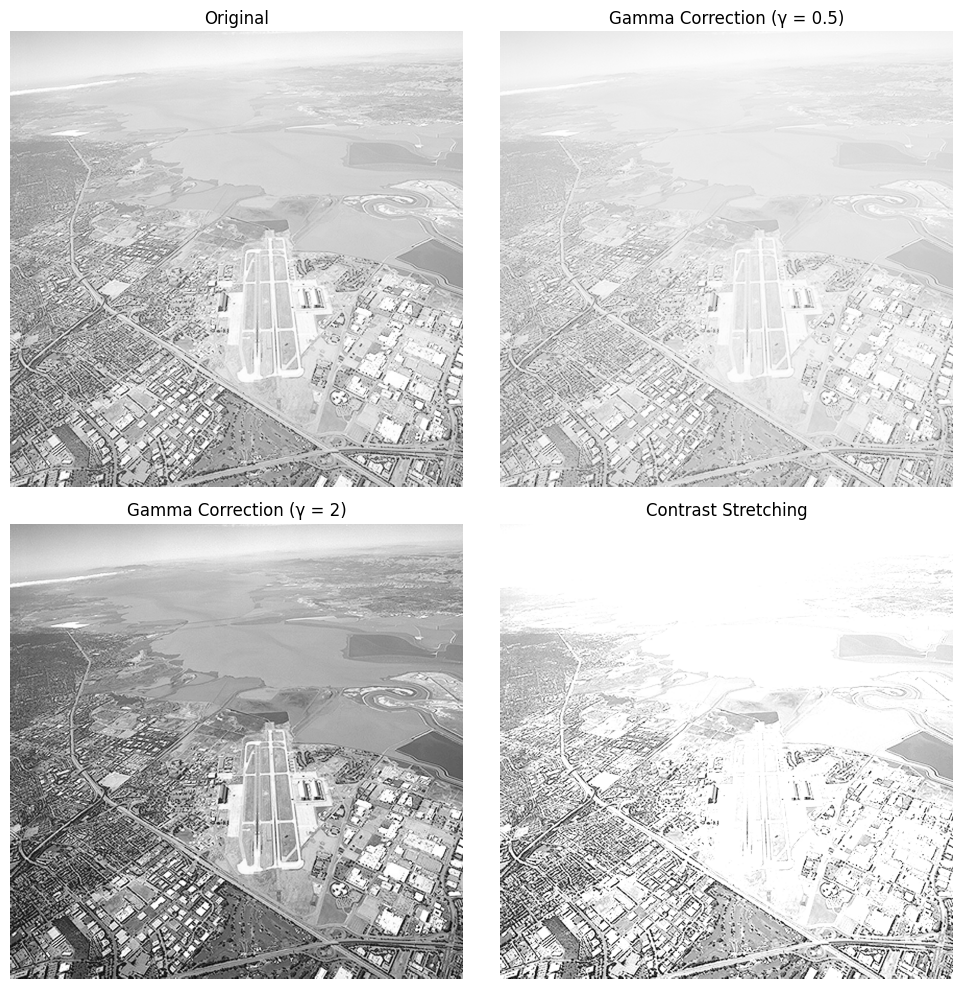

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(gamma_05_u8, cmap="gray")
axes[0, 1].set_title("Gamma Correction (γ = 0.5)")
axes[0, 1].axis("off")

axes[1, 0].imshow(gamma_2_u8, cmap="gray")
axes[1, 0].set_title("Gamma Correction (γ = 2)")
axes[1, 0].axis("off")

axes[1, 1].imshow(contrast_u8, cmap="gray")
axes[1, 1].set_title("Contrast Stretching")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Save outputs

In [7]:
cv2.imwrite(str(output_dir / "original.png"), img)
cv2.imwrite(str(output_dir / "gamma_0_5.png"), gamma_05_u8)
cv2.imwrite(str(output_dir / "gamma_2_0.png"), gamma_2_u8)
cv2.imwrite(str(output_dir / "contrast_stretch.png"), contrast_u8)

True

## Save comparison figure

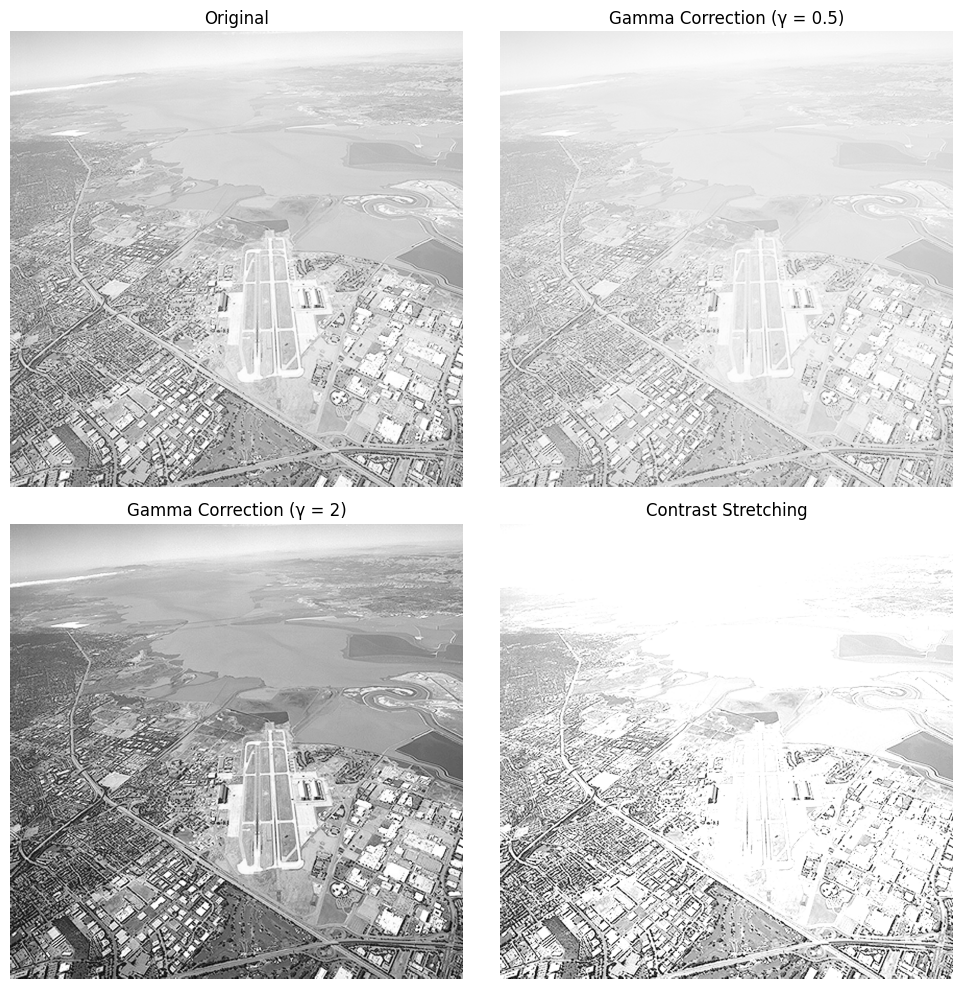

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(gamma_05_u8, cmap="gray")
axes[0, 1].set_title("Gamma Correction (γ = 0.5)")
axes[0, 1].axis("off")

axes[1, 0].imshow(gamma_2_u8, cmap="gray")
axes[1, 0].set_title("Gamma Correction (γ = 2)")
axes[1, 0].axis("off")

axes[1, 1].imshow(contrast_u8, cmap="gray")
axes[1, 1].set_title("Contrast Stretching")
axes[1, 1].axis("off")

plt.tight_layout()
plt.savefig(output_dir / "comparison.png", dpi=300, bbox_inches="tight")
plt.show()